# Determine the variation between the number of instances between WLASL splits

In [1]:
from typing import List
import numpy as np
import matplotlib.pyplot as plt
#locals
from src.configs import get_class_list
from src.video_dataset import get_wlasl_info, get_labels_path, load_data_from_json
from src.preprocess import WLASLClass
from src.stats import (
    AVAIL_SETS,
    AVAIL_SPLITS,
    get_per_instance_stats,
    reverse_preproc_format,
)


In [2]:
split_options: List[AVAIL_SPLITS] = ["asl100", "asl300", "asl1000", "asl2000"]
set_options: List[AVAIL_SETS] = ['train', 'test', 'val']
metric = 'num_instances'
classes = get_class_list()


In [3]:
split_dist = {}
def printv(msg = '', verbose: bool = False):
    if verbose:
        print(msg)
        
for split_name in split_options:
    printv(f'Analyzing split: {split_name}')
    printv('-'*50)
    tot = 0
    all_stats = {}
    for set_name in set_options:
        
        set_path_info = get_wlasl_info(split_name, set_name)
        set_path = get_labels_path(set_name, set_path_info['labels'], set_path_info['label_suff'])
        subset = reverse_preproc_format(
            load_data_from_json(set_path, policy="strict"),
            classes
        )
        
        subset_stats = get_per_instance_stats(
            [WLASLClass.model_validate(i) for i in subset]
        )
        printv(f'Num classes in {set_name}: {len(subset)}')
        
        num_inst_vals = [subset_stats[k][metric] for k in subset_stats.keys()]
        
        tot_set = sum(num_inst_vals)
        tot += tot_set
        median_num_inst = np.round(np.median(num_inst_vals), decimals=2)
        mean_num_inst = np.round(np.mean(num_inst_vals), decimals=2)
        all_stats[set_name] = {
            'median_num_inst': median_num_inst,
            'mean_num_inst': mean_num_inst,
            'total_num_inst': tot_set
        }
        printv(f'Median num instances per class in {set_name}: {median_num_inst}')
        printv(f'Mean num instances per class in {set_name}: {mean_num_inst}')
        printv(f'Total num instances in {set_name}: {tot_set}')
        printv()
        
    split_dist[split_name] = all_stats
    printv(f'Total instances in split {split_name}: {tot}')
    printv('-'*50)
        

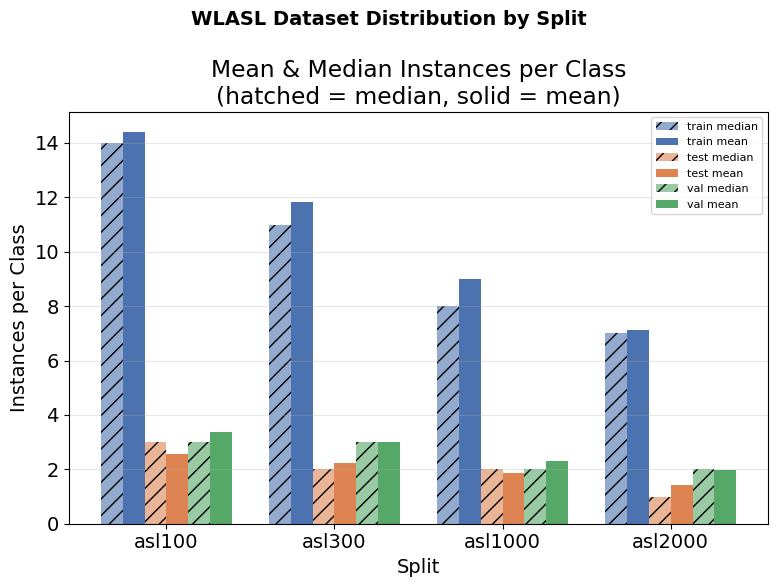

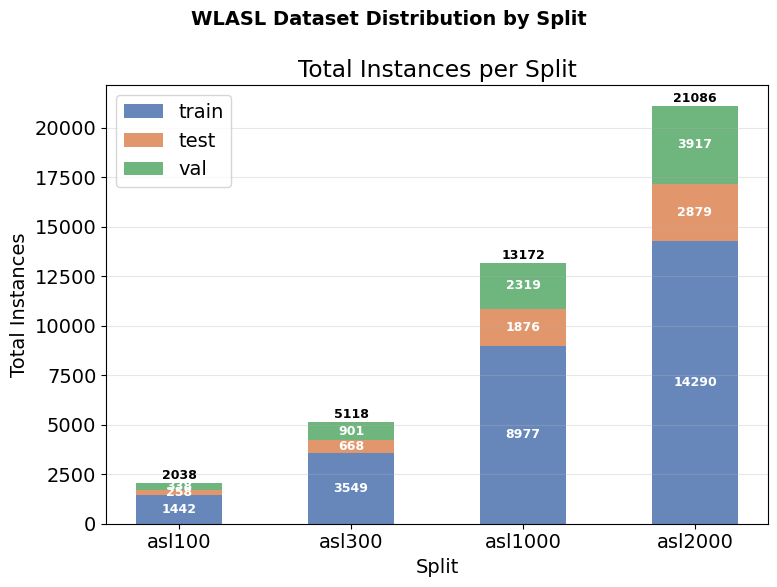

In [9]:
plt.rcParams.update({'font.size': 14}) # Font

splits = list(split_dist.keys())
sets = ['train', 'test', 'val']
x = np.arange(len(splits))
width = 0.13
colors = {'train': '#4C72B0', 'test': '#DD8452', 'val': '#55A868'}

# --- Figure 1: Mean & Median instances per class ---
fig1, ax1 = plt.subplots(figsize=(8, 6))
fig1.suptitle("WLASL Dataset Distribution by Split", fontsize=14, fontweight='bold')

for i, set_name in enumerate(sets):
    medians = [split_dist[s][set_name]['median_num_inst'] for s in splits]
    means   = [split_dist[s][set_name]['mean_num_inst']   for s in splits]

    offset_med  = (i - 1) * 2 * width - width / 2
    offset_mean = (i - 1) * 2 * width + width / 2

    ax1.bar(x + offset_med,  medians, width, label=f'{set_name} median',
            color=colors[set_name], alpha=0.6, hatch='//')
    ax1.bar(x + offset_mean, means,   width, label=f'{set_name} mean',
            color=colors[set_name], alpha=1.0)

ax1.set_xticks(x)
ax1.set_xticklabels(splits)
ax1.set_xlabel("Split")
ax1.set_ylabel("Instances per Class")
ax1.set_title("Mean & Median Instances per Class\n(hatched = median, solid = mean)")
ax1.legend(fontsize=8)
ax1.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/wlasl_mean_median.pdf", dpi=150, bbox_inches='tight')
plt.show()


# --- Figure 2: Total instances per split (stacked bar) ---
fig2, ax2 = plt.subplots(figsize=(8, 6))
fig2.suptitle("WLASL Dataset Distribution by Split", fontsize=14, fontweight='bold')

bottoms = np.zeros(len(splits))
for set_name in sets:
    totals = [split_dist[s][set_name]['total_num_inst'] for s in splits]
    bars = ax2.bar(x, totals, width=0.5, bottom=bottoms,
                   label=set_name, color=colors[set_name], alpha=0.85)
    for bar, val, bot in zip(bars, totals, bottoms):
        ax2.text(bar.get_x() + bar.get_width() / 2,
                 bot + val / 2, str(val),
                 ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    bottoms += np.array(totals)

for xi, bot in zip(x, bottoms):
    ax2.text(xi, bot + 50, str(int(bot)), ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.set_xticks(x)
ax2.set_xticklabels(splits)
ax2.set_xlabel("Split")
ax2.set_ylabel("Total Instances")
ax2.set_title("Total Instances per Split")
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/wlasl_totals.pdf", dpi=150, bbox_inches='tight')
plt.show()